In [1]:
from soilgrids import SoilGrids
import matplotlib.pyplot as plt

# TODO: run analysis of statistal comparison of soilgrids data with field data
# parameters to compare: permanent wilting point, field capacity, saturation point, bulk density
# the data consists of two locations with various sites from burned areas and also from reference sites. 


In [2]:
# first we will need to get the soilgrids data from the soilgrids library and extract the coordinates needed ie. the site locations
# site locations are located here: C:\Soilgrids\datos_martha\sites_Llaviuco.csv and C:\Soilgrids\datos_martha\sites_Yansascha.csv
# we will need to read the csv files and extract the coordinates
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Read the CSV files
sites_llaviuco = pd.read_csv('datos_martha/sites_Llaviuco_clean.csv')
sites_yansascha = pd.read_csv('datos_martha/sites_Yanasascha_clean.csv')

# Combine both datasets
all_sites = pd.concat([sites_llaviuco, sites_yansascha], ignore_index=True)

print(f"Total sites: {len(all_sites)}")
print(f"Llaviuco sites: {len(sites_llaviuco)}")
print(f"Yansascha sites: {len(sites_yansascha)}")
print("\nFirst few sites:")
print(all_sites.head())


Total sites: 24
Llaviuco sites: 9
Yansascha sites: 15

First few sites:
  Reference       Lat        Lon  Elevation        Date  dNBR
0       LR1 -2.806780 -79.159910       3560  25/11/2025   NaN
1       LR2 -2.815830 -79.156100       3685  25/11/2025   NaN
2       LR3 -2.834869 -79.138083       3495  15/01/2026   NaN
3       LR4 -2.832440 -79.142684       3607  15/01/2026   NaN
4       LB1 -2.806710 -79.160220       3585  25/11/2025   0.3


In [3]:

import tempfile
import os
import numpy as np

# Register wv* services not included in soilgrids v0.1.5
for wv_id, wv_name in [('wv0010', '10kPa'), ('wv0033', '33kPa'), ('wv1500', '1500kPa')]:
    SoilGrids.MAP_SERVICES[wv_id] = {
        'name': f'Volumetric water content at {wv_name}',
        'link': f'https://maps.isric.org/mapserv?map=/map/{wv_id}.map',
        'units': 'cm3/dm3 (vol‰)',
    }

sg = SoilGrids()

# Properties to fetch
prop_ids = ['bdod', 'phh2o', 'wv0010', 'wv0033', 'wv1500']

# Three SoilGrids depth layers needed
sg_depth_layers = ['0-5cm', '5-15cm', '15-30cm']

# Depth-weighted averages mapping field cores to SoilGrids layers
# Field 0–10 cm:  5 cm from (0-5cm)  + 5 cm from (5-15cm)  → 50% / 50%
# Field 10–20 cm: 5 cm from (5-15cm) + 5 cm from (15-30cm) → 50% / 50%
field_depth_weights = {
    '0_10cm':  {'0-5cm': 0.5, '5-15cm': 0.5},
    '10_20cm': {'5-15cm': 0.5, '15-30cm': 0.5},
}

CRS_WGS84 = 'urn:ogc:def:crs:EPSG::4326'
tmpdir = tempfile.mkdtemp()

soilgrids_data = []

for idx, row in all_sites.iterrows():
    lat = row['Lat']
    lon = row['Lon']
    site_id = row['Reference']
    offset = 0.001

    try:
        site_data = {'Reference': site_id, 'Lat': lat, 'Lon': lon}

        # Fetch all three depth layers for each property
        raw_vals = {prop: {} for prop in prop_ids}

        for prop in prop_ids:
            for depth_lyr in sg_depth_layers:
                coverage_id = f'{prop}_{depth_lyr}_mean'
                out_file = os.path.join(tmpdir, f"{site_id}_{prop}_{depth_lyr.replace('-', '_')}.tif")
                try:
                    dataset = sg.get_coverage_data(
                        service_id=prop,
                        coverage_id=coverage_id,
                        crs=CRS_WGS84,
                        west=lon - offset, south=lat - offset,
                        east=lon + offset, north=lat + offset,
                        width=1, height=1,
                        output=out_file,
                    )
                    val = float(dataset.values[0, 0, 0])
                    raw_vals[prop][depth_lyr] = val if val != -32768 else None
                except Exception as e:
                    raw_vals[prop][depth_lyr] = None
                    print(f"  Warning: {prop} {depth_lyr} for {site_id}: {str(e)[:100]}")

        # Compute depth-weighted averages for each field depth interval
        for field_depth, weights in field_depth_weights.items():
            for prop in prop_ids:
                layer_vals = [raw_vals[prop].get(lyr) for lyr in weights]
                wts = list(weights.values())
                if all(v is not None for v in layer_vals):
                    site_data[f'{prop}_{field_depth}'] = sum(v * w for v, w in zip(layer_vals, wts))
                else:
                    site_data[f'{prop}_{field_depth}'] = None

        soilgrids_data.append(site_data)
        print(f"✓ Retrieved data for {site_id}")

    except Exception as e:
        print(f"✗ Error for {site_id}: {str(e)}")

soilgrids_df = pd.DataFrame(soilgrids_data)
print(f"\nSoilGrids data retrieved for {len(soilgrids_df)} sites")
print(soilgrids_df.head())


✓ Retrieved data for LR1
✓ Retrieved data for LR2
✓ Retrieved data for LR3
✓ Retrieved data for LR4
✓ Retrieved data for LB1
✓ Retrieved data for LB2
✓ Retrieved data for LB3
✓ Retrieved data for LB4
✓ Retrieved data for LB5
✓ Retrieved data for YL1
✓ Retrieved data for YL2
✓ Retrieved data for YL3
✓ Retrieved data for YL4
✓ Retrieved data for YL5
✓ Retrieved data for YH1
✓ Retrieved data for YH2
✓ Retrieved data for YH3
✓ Retrieved data for YH4
✓ Retrieved data for YH5
✓ Retrieved data for YR1
✓ Retrieved data for YR2
✓ Retrieved data for YR3
✓ Retrieved data for YR4
✓ Retrieved data for YR5

SoilGrids data retrieved for 24 sites
  Reference       Lat        Lon  bdod_0_10cm  phh2o_0_10cm  wv0010_0_10cm  \
0       LR1 -2.806780 -79.159910        103.0          53.0          433.0   
1       LR2 -2.815830 -79.156100         99.5          52.0          430.0   
2       LR3 -2.834869 -79.138083        100.5          55.0          431.5   
3       LR4 -2.832440 -79.142684        101.0    

In [4]:

# Save the SoilGrids weighted averages for key hydraulic properties (both depth intervals)
key_props = ['bdod', 'wv0010', 'wv0033', 'wv1500']
wc_cols = ['Reference', 'Lat', 'Lon'] + [f'{p}_{d}' for p in key_props for d in ['0_10cm', '10_20cm']]

soilgrids_wc = soilgrids_df[wc_cols].copy()

output_path = 'soilgrids_water_content_bulk_density.csv'
soilgrids_wc.to_csv(output_path, index=False)

print(f"✓ Saved {len(soilgrids_wc)} sites (2 depth intervals each) to '{output_path}'")
print(soilgrids_wc.to_string())


✓ Saved 24 sites (2 depth intervals each) to 'soilgrids_water_content_bulk_density.csv'
   Reference       Lat        Lon  bdod_0_10cm  bdod_10_20cm  wv0010_0_10cm  wv0010_10_20cm  wv0033_0_10cm  wv0033_10_20cm  wv1500_0_10cm  wv1500_10_20cm
0        LR1 -2.806780 -79.159910        103.0         107.5          433.0           413.0          327.0           323.5          172.0           169.0
1        LR2 -2.815830 -79.156100         99.5         104.5          430.0           411.0          346.0           342.5          159.0           156.5
2        LR3 -2.834869 -79.138083        100.5         105.0          431.5           421.5          359.0           358.0          189.5           189.5
3        LR4 -2.832440 -79.142684        101.0         106.0          430.0           415.5          363.0           359.0          174.0           172.5
4        LB1 -2.806710 -79.160220        103.0         107.0          435.0           413.0          325.0           322.5          163.5     

In [5]:

# Load field measurements (both 0-10 cm and 10-20 cm depth intervals)
field_raw = pd.read_csv('datos_martha/results_summary.csv', usecols=range(7))
field_raw.columns = [
    'sample_code', 'organic_matter_pct', 'pH_field',
    'bulk_density_field_g_cm3',
    'vwc_sat_field_cm3cm3',        # pF 0   – Saturation
    'vwc_field_cap_field_cm3cm3',  # pF 2.52 – Field capacity
    'vwc_wilt_pt_field_cm3cm3',    # pF 4.2  – Wilting point
]
field_raw = field_raw.dropna(subset=['sample_code'])
field_raw['Reference'] = field_raw['sample_code'].str.extract(r'^(\S+)')
field_raw['depth'] = field_raw['sample_code'].str.extract(r'(\d+-\d+)$')

group_map = {
    'LR': 'Llaviuco_Reference',
    'LB': 'Llaviuco_Burned',
    'YL': 'Yanasacha_Low_Burn',
    'YH': 'Yanasacha_High_Burn',
    'YR': 'Yanasacha_Reference',
}
field_raw['group'] = field_raw['Reference'].str[:2].map(group_map)

# Reshape SoilGrids from wide (one row per site, columns per depth)
# to long (one row per site × depth), matching field data structure
depth_label_map = {'0-10': '0_10cm', '10-20': '10_20cm'}

sg_rows = []
for _, sg_row in soilgrids_df.iterrows():
    for field_depth, sg_suffix in depth_label_map.items():
        r = {
            'Reference': sg_row['Reference'],
            'Lat': sg_row['Lat'],
            'Lon': sg_row['Lon'],
            'depth': field_depth,
        }
        for prop in prop_ids:
            r[prop] = sg_row.get(f'{prop}_{sg_suffix}')
        sg_rows.append(r)
sg_long = pd.DataFrame(sg_rows)

# Convert SoilGrids units to match field data
#   bdod:  cg/cm³  → g/cm³      (÷ 100)
#   phh2o: pH × 10 → pH         (÷ 10)
#   wv***  cm³/dm³ → cm³/cm³    (÷ 1000, because 1 dm³ = 1000 cm³)
#          rioxarray returns already-scaled cm³/dm³ values from the GeoTIFF
sg_long['bdod_sg_g_cm3']       = sg_long['bdod']   / 100
sg_long['phh2o_sg']            = sg_long['phh2o']  / 10
sg_long['vwc_10kPa_sg_cm3cm3'] = sg_long['wv0010'] / 1000   # near-saturation proxy
sg_long['vwc_fc_sg_cm3cm3']    = sg_long['wv0033'] / 1000   # field capacity
sg_long['vwc_wp_sg_cm3cm3']    = sg_long['wv1500'] / 1000   # wilting point
sg_long = sg_long.drop(columns=prop_ids)

# Merge: field measurements + site metadata + SoilGrids data
field_cols = ['Reference', 'depth', 'group', 'organic_matter_pct', 'pH_field',
              'bulk_density_field_g_cm3', 'vwc_sat_field_cm3cm3',
              'vwc_field_cap_field_cm3cm3', 'vwc_wilt_pt_field_cm3cm3']

combined = (
    field_raw[field_cols]
    .merge(all_sites[['Reference', 'Lat', 'Lon', 'Elevation', 'Date', 'dNBR']],
           on='Reference', how='left')
    .merge(sg_long, on=['Reference', 'Lat', 'Lon', 'depth'], how='left')
)

output_path = 'combined_field_soilgrids.csv'
combined.to_csv(output_path, index=False)

print(f"✓ Saved combined dataset to '{output_path}'")
print(f"  {len(combined)} rows ({len(combined)//2} sites × 2 depths)  |  {combined.shape[1]} columns")
print(f"\nUnit check — SoilGrids vs field ranges:")
for sg_col, field_col, label in [
    ('bdod_sg_g_cm3',       'bulk_density_field_g_cm3',   'Bulk density (g/cm³)'),
    ('vwc_fc_sg_cm3cm3',    'vwc_field_cap_field_cm3cm3', 'Field capacity (cm³/cm³)'),
    ('vwc_wp_sg_cm3cm3',    'vwc_wilt_pt_field_cm3cm3',   'Wilting point (cm³/cm³)'),
    ('vwc_10kPa_sg_cm3cm3', 'vwc_sat_field_cm3cm3',       'Near-sat / Sat (cm³/cm³)'),
]:
    sg_range   = f"{combined[sg_col].min():.3f}–{combined[sg_col].max():.3f}"
    fld_range  = f"{combined[field_col].min():.3f}–{combined[field_col].max():.3f}"
    print(f"  {label:<35} SG: {sg_range:<15} Field: {fld_range}")


✓ Saved combined dataset to 'combined_field_soilgrids.csv'
  48 rows (24 sites × 2 depths)  |  19 columns

Unit check — SoilGrids vs field ranges:
  Bulk density (g/cm³)                SG: 0.990–1.110     Field: 0.173–0.556
  Field capacity (cm³/cm³)            SG: 0.319–0.388     Field: 0.459–0.704
  Wilting point (cm³/cm³)             SG: 0.151–0.190     Field: 0.181–0.483
  Near-sat / Sat (cm³/cm³)            SG: 0.392–0.435     Field: 0.736–0.957


In [6]:
import pandas as pd
import numpy as np

# Load combined dataset if it is not already in memory
try:
    combined
except NameError:
    combined = pd.read_csv('combined_field_soilgrids.csv')

# Keep only field-measured variables for the introductory summary
field_vars = [
    'bulk_density_field_g_cm3',
    'vwc_sat_field_cm3cm3',
    'vwc_field_cap_field_cm3cm3',
    'vwc_wilt_pt_field_cm3cm3',
    'organic_matter_pct',
    'pH_field',
]

metric_labels = {
    'bulk_density_field_g_cm3': 'Bulk density (g/cm3)',
    'vwc_sat_field_cm3cm3': 'Vol. water content at saturation (cm3/cm3)',
    'vwc_field_cap_field_cm3cm3': 'Vol. water content at field capacity (cm3/cm3)',
    'vwc_wilt_pt_field_cm3cm3': 'Vol. water content at wilting point (cm3/cm3)',
    'organic_matter_pct': 'Organic matter (%)',
    'pH_field': 'pH',
}

group_order = [
    'Llaviuco_Reference',
    'Llaviuco_Burned',
    'Yanasacha_Reference',
    'Yanasacha_Low_Burn',
    'Yanasacha_High_Burn',
]

field_df = combined[['Reference', 'group', 'depth'] + field_vars].copy()
field_df = field_df.dropna(subset=['Reference', 'group', 'depth'])
field_df['group'] = pd.Categorical(field_df['group'], categories=group_order, ordered=True)

# 1) Sampling coverage table (good for first presentation slide)
sample_table = (
    field_df.groupby('group', observed=True)
    .agg(
        n_sites=('Reference', 'nunique'),
        n_observations=('Reference', 'size'),
    )
    .reset_index()
    .sort_values('group')
)

# 2) Descriptive statistics table by group and depth
long_df = field_df.melt(
    id_vars=['Reference', 'group', 'depth'],
    value_vars=field_vars,
    var_name='metric',
    value_name='value',
).dropna(subset=['value'])

summary_table = (
    long_df.groupby(['group', 'depth', 'metric'], observed=True)['value']
    .agg(['count', 'mean', 'std', 'min', 'max'])
    .reset_index()
    .rename(columns={'count': 'n'})
)
summary_table['metric'] = summary_table['metric'].map(metric_labels)
summary_table = summary_table.rename(columns={
    'group': 'site_group',
    'depth': 'depth_cm',
    'metric': 'field_metric',
    'mean': 'mean_value',
    'std': 'std_value',
    'min': 'min_value',
    'max': 'max_value',
})

for col in ['mean_value', 'std_value', 'min_value', 'max_value']:
    summary_table[col] = summary_table[col].round(3)

# Save for reporting
sample_table.to_csv('resultados/field_sampling_summary.csv', index=False)
summary_table.to_csv('resultados/field_descriptive_summary.csv', index=False)

print('Field data summary tables created:')
print(' - resultados/field_sampling_summary.csv')
print(' - resultados/field_descriptive_summary.csv')

print('\nSampling coverage by group:')
display(sample_table)

print('\nDescriptive statistics by group, depth, and metric:')
display(summary_table)

Field data summary tables created:
 - resultados/field_sampling_summary.csv
 - resultados/field_descriptive_summary.csv

Sampling coverage by group:


,group,n_sites,n_observations
0,Llaviuco_Reference,4,8
1,Llaviuco_Burned,5,10
2,Yanasacha_Reference,5,10
3,Yanasacha_Low_Burn,5,10
4,Yanasacha_High_Burn,5,10



Descriptive statistics by group, depth, and metric:


,site_group,depth_cm,field_metric,n,mean_value,std_value,min_value,max_value
0,Llaviuco_Reference,0-10,Bulk density (g/cm3),4,0.367,0.094,0.265,0.489
1,Llaviuco_Reference,0-10,Organic matter (%),4,46.228,11.666,28.850,53.680
2,Llaviuco_Reference,0-10,pH,4,5.852,0.419,5.360,6.270
3,Llaviuco_Reference,0-10,Vol. water content at field capacity (cm3/cm3),4,0.648,0.025,0.611,0.665
4,Llaviuco_Reference,0-10,Vol. water content at saturation (cm3/cm3),4,0.821,0.028,0.788,0.855
5,Llaviuco_Reference,0-10,Vol. water content at wilting point (cm3/cm3),4,0.334,0.024,0.301,0.359
6,Llaviuco_Reference,10-20,Bulk density (g/cm3),4,0.385,0.114,0.294,0.550
7,Llaviuco_Reference,10-20,Organic matter (%),4,45.688,12.118,27.520,52.170
8,Llaviuco_Reference,10-20,pH,4,5.970,0.559,5.290,6.640
9,Llaviuco_Reference,10-20,Vol. water content at field capacity (cm3/cm3),4,0.669,0.021,0.637,0.680


Parameter                     n     Bias     RMSE     r_s   p (Wilcox)   SG CV%
------------------------------------------------------------------------------------------
Bulk density                 48  +0.6999   0.7066   0.144       0.0000     3.1%
Field capacity               48  -0.2701   0.2803  -0.581       0.0000     5.7%
Wilting point                48  -0.1593   0.1690   0.145       0.0000     4.4%
Near-sat. (≈pF 1)*           48  -0.4088   0.4115  -0.282       0.0000     3.0%
SG CV% = coefficient of variation of SoilGrids values across sites (low = spatially flat)
* Near-saturation comparison is approximate: field pF 0 ≠ SoilGrids wv0010 (10 kPa)


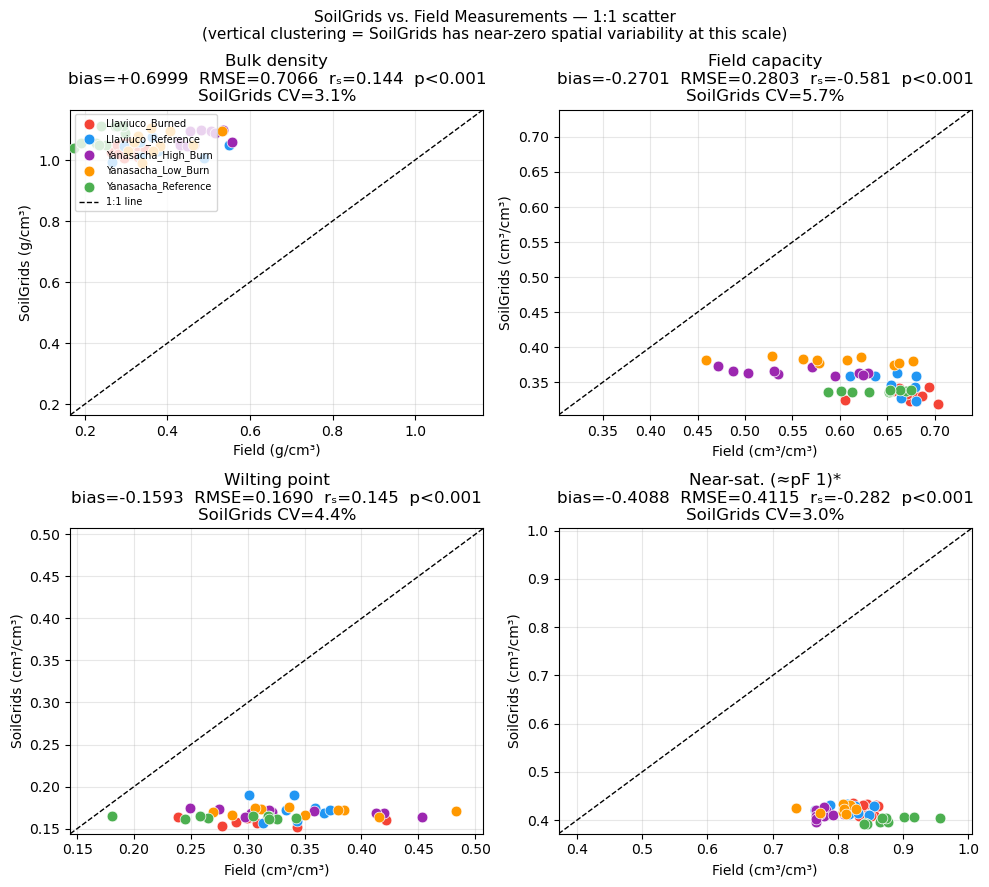

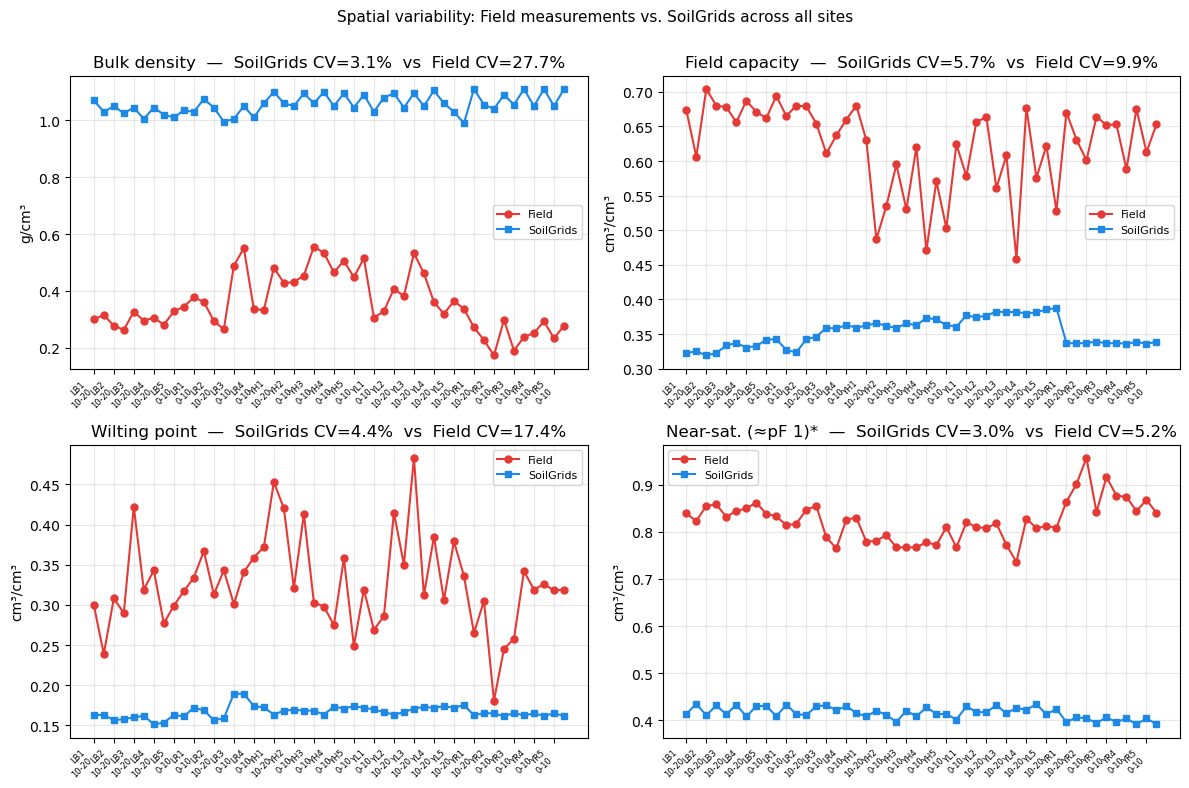

✓ Figures saved.


In [7]:

from scipy import stats
import matplotlib.pyplot as plt

# Load the combined dataset (re-read so this cell is self-contained)
combined = pd.read_csv('combined_field_soilgrids.csv')

# Parameter pairs: (label, field column, SoilGrids column, unit)
# Note: saturation comparison is approximate — field pF 0 ≠ SoilGrids wv0010 (pF 1 / 10 kPa)
param_pairs = [
    ('Bulk density',        'bulk_density_field_g_cm3',   'bdod_sg_g_cm3',       'g/cm³'),
    ('Field capacity',      'vwc_field_cap_field_cm3cm3', 'vwc_fc_sg_cm3cm3',    'cm³/cm³'),
    ('Wilting point',       'vwc_wilt_pt_field_cm3cm3',   'vwc_wp_sg_cm3cm3',    'cm³/cm³'),
    ('Near-sat. (≈pF 1)*', 'vwc_sat_field_cm3cm3',       'vwc_10kPa_sg_cm3cm3', 'cm³/cm³'),
]

group_colors = {
    'Llaviuco_Reference': '#2196F3',
    'Llaviuco_Burned':    '#F44336',
    'Yanasacha_Low_Burn': '#FF9800',
    'Yanasacha_High_Burn':'#9C27B0',
    'Yanasacha_Reference':'#4CAF50',
}

# ── Statistical summary table ──────────────────────────────────────────────
print("=" * 90)
print(f"{'Parameter':<26} {'n':>4} {'Bias':>8} {'RMSE':>8} {'r_s':>7} {'p (Wilcox)':>12} {'SG CV%':>8}")
print("-" * 90)

stat_results = []
for label, field_col, sg_col, unit in param_pairs:
    df = combined[[field_col, sg_col]].dropna()
    n = len(df)
    if n < 4:
        continue

    field_vals = df[field_col].values
    sg_vals    = df[sg_col].values

    bias      = float(np.mean(sg_vals - field_vals))
    rmse      = float(np.sqrt(np.mean((sg_vals - field_vals) ** 2)))
    rs, _     = stats.spearmanr(field_vals, sg_vals)
    _, p_wilcox = stats.wilcoxon(field_vals, sg_vals)
    # Coefficient of variation of SoilGrids values — shows how little SG varies spatially
    sg_cv = float(np.std(sg_vals) / np.mean(sg_vals) * 100)

    print(f"{label:<26} {n:>4} {bias:>+8.4f} {rmse:>8.4f} {rs:>7.3f} {p_wilcox:>12.4f} {sg_cv:>7.1f}%")
    stat_results.append(dict(label=label, n=n, bias=bias, rmse=rmse, rs=rs,
                              p_wilcox=p_wilcox, sg_cv=sg_cv,
                              field_col=field_col, sg_col=sg_col, unit=unit))

print("=" * 90)
print("SG CV% = coefficient of variation of SoilGrids values across sites (low = spatially flat)")
print("* Near-saturation comparison is approximate: field pF 0 ≠ SoilGrids wv0010 (10 kPa)")

# ── Figure 1: 1:1 scatter plots ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.flatten()

for ax, res in zip(axes, stat_results):
    df_plot = combined[[res['field_col'], res['sg_col'], 'group']].dropna()
    for grp, gdf in df_plot.groupby('group'):
        ax.scatter(gdf[res['field_col']], gdf[res['sg_col']],
                   label=grp, color=group_colors.get(grp, 'grey'),
                   s=60, edgecolors='white', linewidths=0.5, zorder=3)

    all_vals = pd.concat([df_plot[res['field_col']], df_plot[res['sg_col']]])
    lims = [all_vals.min() * 0.95, all_vals.max() * 1.05]
    ax.plot(lims, lims, 'k--', lw=1, label='1:1 line')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f"Field ({res['unit']})")
    ax.set_ylabel(f"SoilGrids ({res['unit']})")
    p_str = f"p={res['p_wilcox']:.3f}" if res['p_wilcox'] >= 0.001 else "p<0.001"
    ax.set_title(f"{res['label']}\nbias={res['bias']:+.4f}  RMSE={res['rmse']:.4f}"
                 f"  rₛ={res['rs']:.3f}  {p_str}\nSoilGrids CV={res['sg_cv']:.1f}%")
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=7, loc='upper left')
fig.suptitle("SoilGrids vs. Field Measurements — 1:1 scatter\n"
             "(vertical clustering = SoilGrids has near-zero spatial variability at this scale)",
             fontsize=11)
plt.tight_layout()
plt.savefig('soilgrids_vs_field_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Spatial variability comparison (field vs SoilGrids range) ───
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 8))
axes2 = axes2.flatten()

for ax, res in zip(axes2, stat_results):
    df_plot = combined[[res['field_col'], res['sg_col'], 'Reference', 'depth']].dropna()
    df_plot = df_plot.sort_values('Reference')
    x = range(len(df_plot))

    ax.plot(x, df_plot[res['field_col']].values, 'o-', color='#E53935', label='Field', ms=5)
    ax.plot(x, df_plot[res['sg_col']].values,    's-', color='#1E88E5', label='SoilGrids', ms=5)

    ax.set_xticks(list(x)[::2])
    ax.set_xticklabels(
        [f"{r}\n{d}" for r, d in zip(df_plot['Reference'].values[::2], df_plot['depth'].values[::2])],
        fontsize=6, rotation=45, ha='right'
    )
    ax.set_ylabel(res['unit'])
    ax.set_title(f"{res['label']}  —  SoilGrids CV={res['sg_cv']:.1f}%  vs  "
                 f"Field CV={np.std(df_plot[res['field_col']].values)/np.mean(df_plot[res['field_col']].values)*100:.1f}%")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig2.suptitle("Spatial variability: Field measurements vs. SoilGrids across all sites\n",
              fontsize=11)
plt.tight_layout()
plt.savefig('soilgrids_vs_field_spatial_variability.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figures saved.")


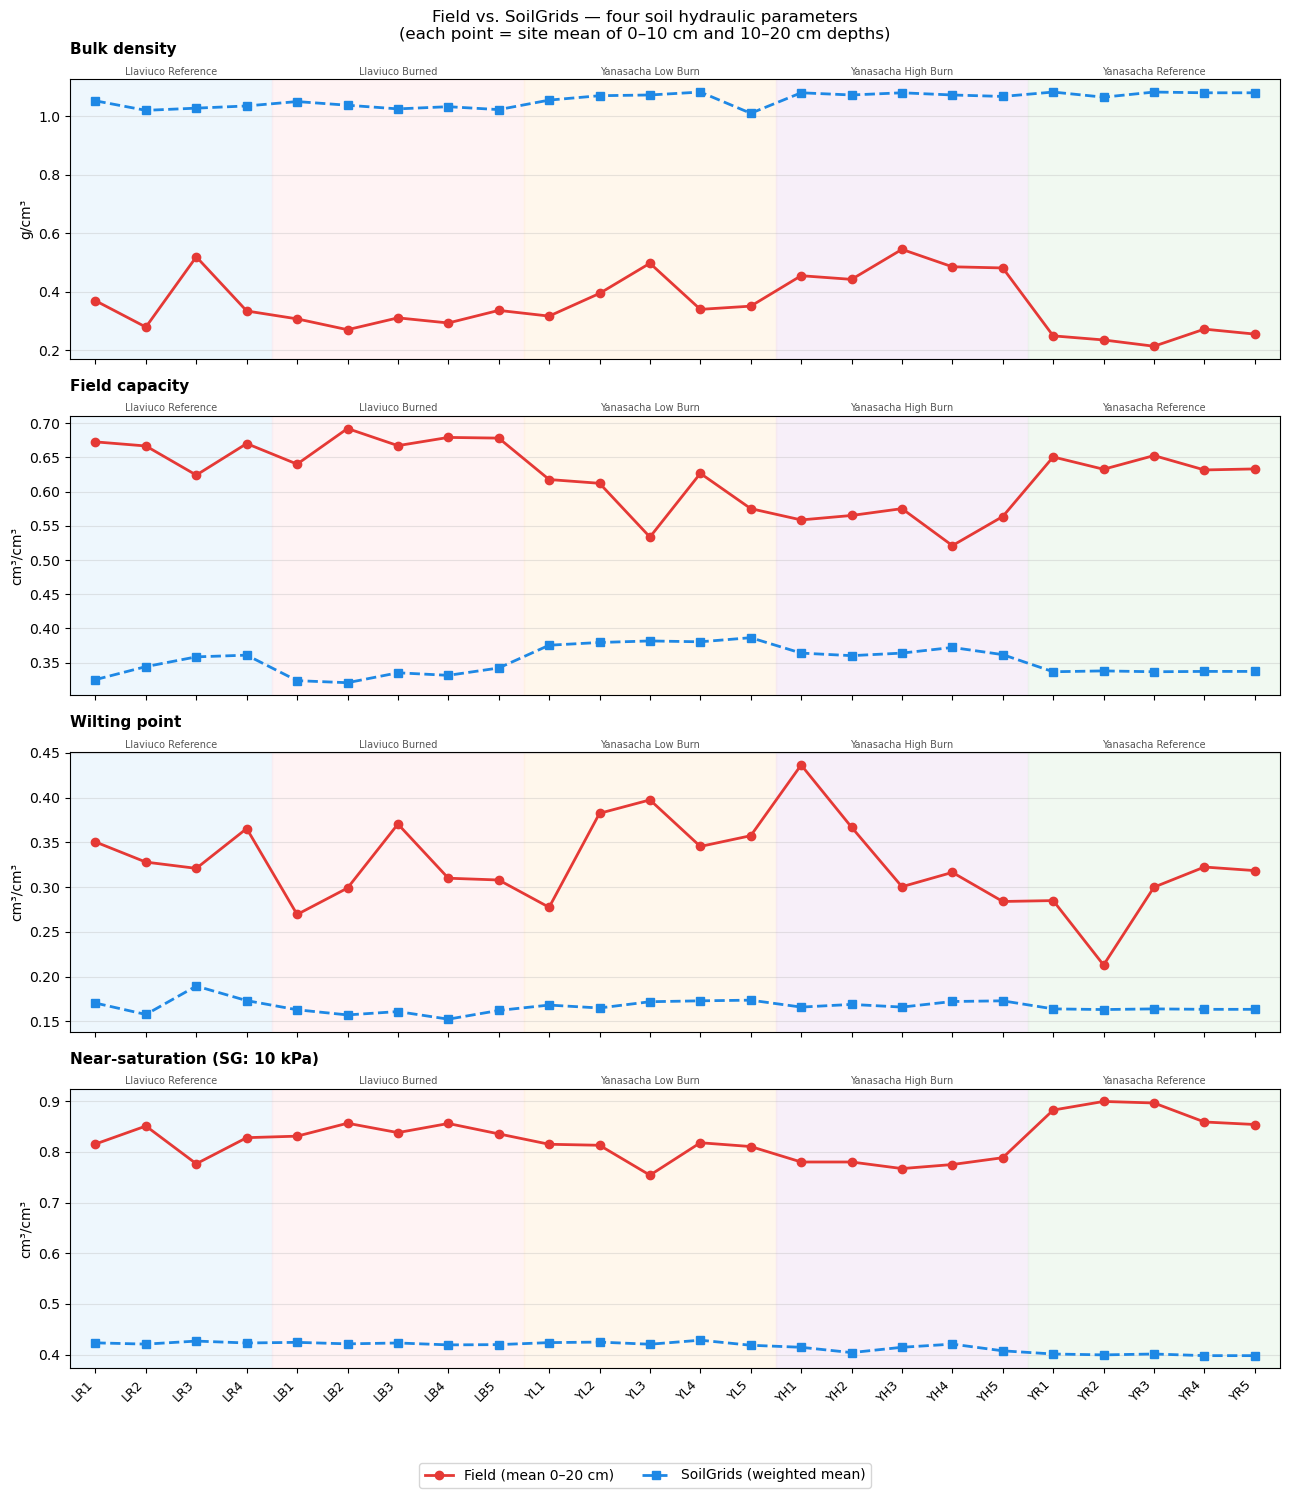

✓ Saved to 'field_vs_soilgrids_linecharts.png'


In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

combined = pd.read_csv('combined_field_soilgrids.csv')

param_pairs = [
    ('Bulk density',         'bulk_density_field_g_cm3',   'bdod_sg_g_cm3',       'g/cm³'),
    ('Field capacity',       'vwc_field_cap_field_cm3cm3', 'vwc_fc_sg_cm3cm3',    'cm³/cm³'),
    ('Wilting point',        'vwc_wilt_pt_field_cm3cm3',   'vwc_wp_sg_cm3cm3',    'cm³/cm³'),
    ('Near-saturation (SG: 10 kPa)', 'vwc_sat_field_cm3cm3', 'vwc_10kPa_sg_cm3cm3', 'cm³/cm³'),
]

site_avg = combined.groupby('Reference')[
    [p[1] for p in param_pairs] + [p[2] for p in param_pairs]
].mean().reset_index()

prefix_order = {'LR': 0, 'LB': 1, 'YL': 2, 'YH': 3, 'YR': 4}
site_avg['_order'] = site_avg['Reference'].str[:2].map(prefix_order) * 100 + \
                     site_avg['Reference'].str[2:].str.extract(r'(\d+)')[0].astype(float)
site_avg = site_avg.sort_values('_order').drop(columns='_order')
sites = site_avg['Reference'].tolist()
x = range(len(sites))

group_bounds = []
current = site_avg['Reference'].str[:2].iloc[0]
start = 0
for i, ref in enumerate(site_avg['Reference']):
    if ref[:2] != current:
        group_bounds.append((start, i - 1, current))
        current = ref[:2]
        start = i
group_bounds.append((start, len(sites) - 1, current))

group_labels = {
    'LR': 'Llaviuco Reference', 'LB': 'Llaviuco Burned',
    'YL': 'Yanasacha Low Burn', 'YH': 'Yanasacha High Burn',
    'YR': 'Yanasacha Reference',
}
group_shades = ['#E3F2FD', '#FFEBEE', '#FFF3E0', '#F3E5F5', '#E8F5E9']

fig, axes = plt.subplots(4, 1, figsize=(13, 15), sharex=True)

for ax, (label, field_col, sg_col, unit) in zip(axes, param_pairs):
    for (s, e, grp), shade in zip(group_bounds, group_shades):
        ax.axvspan(s - 0.5, e + 0.5, color=shade, alpha=0.6, zorder=0)

    line_field, = ax.plot(x, site_avg[field_col].values, 'o-', color='#E53935',
                          lw=2, ms=6, label='Field (mean 0–20 cm)')
    line_sg, = ax.plot(x, site_avg[sg_col].values, 's--', color='#1E88E5',
                       lw=2, ms=6, label='SoilGrids (weighted mean)')

    ax.set_ylabel(unit, fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold', loc='left', pad=18)
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_xlim(-0.5, len(sites) - 0.5)

    # Group labels above the data using a blended transform:
    # x in data coordinates (centres on each group), y in axes coordinates (top)
    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    for (s, e, grp) in group_bounds:
        ax.text((s + e) / 2, 1.01, group_labels.get(grp, grp),
                transform=trans, ha='center', va='bottom',
                fontsize=7, color='#555555', clip_on=False)

axes[-1].set_xticks(list(x))
axes[-1].set_xticklabels(sites, rotation=45, ha='right', fontsize=9)

fig.legend(
    handles=[line_field, line_sg],
    labels=['Field (mean 0–20 cm)', 'SoilGrids (weighted mean)'],
    loc='lower center',
    ncol=2,
    fontsize=10,
    frameon=True,
    bbox_to_anchor=(0.5, -0.01),
)

fig.suptitle('Field vs. SoilGrids — four soil hydraulic parameters\n(each point = site mean of 0–10 cm and 10–20 cm depths)',
             fontsize=12)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('field_vs_soilgrids_linecharts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved to 'field_vs_soilgrids_linecharts.png'")


In [9]:

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

combined = pd.read_csv('combined_field_soilgrids.csv')

param_pairs = [
    ('Bulk density',             'bulk_density_field_g_cm3',   'bdod_sg_g_cm3',       'g/cm³'),
    ('Field capacity',           'vwc_field_cap_field_cm3cm3', 'vwc_fc_sg_cm3cm3',    'cm³/cm³'),
    ('Wilting point',            'vwc_wilt_pt_field_cm3cm3',   'vwc_wp_sg_cm3cm3',    'cm³/cm³'),
    ('Near-saturation (10 kPa)','vwc_sat_field_cm3cm3',        'vwc_10kPa_sg_cm3cm3', 'cm³/cm³'),
]

group_colors = {
    'Llaviuco_Reference': '#2196F3',
    'Llaviuco_Burned':    '#F44336',
    'Yanasacha_Low_Burn': '#FF9800',
    'Yanasacha_High_Burn':'#9C27B0',
    'Yanasacha_Reference':'#4CAF50',
}

print(f"Dataset: {len(combined)} observations  |  {combined['Reference'].nunique()} sites × 2 depths")
print(combined.groupby('group').size().rename('n').to_string())


Dataset: 48 observations  |  24 sites × 2 depths
group
Llaviuco_Burned        10
Llaviuco_Reference      8
Yanasacha_High_Burn    10
Yanasacha_Low_Burn     10
Yanasacha_Reference    10


In [11]:

import os
import pandas as pd

# ── Paired Wilcoxon signed-rank test (Field vs SoilGrids) ─────────────────
# H0: median difference between field and SoilGrids = 0 (two-sided)
# Each matched pair is one site x depth observation.

print("Paired Wilcoxon Signed-Rank Test — Field vs SoilGrids")
print("=" * 68)
print(f"{'Parameter':<32} {'n':>4}  {'W statistic':>12}  {'p-value':>9}  Result")
print("-" * 68)

wilcoxon_rows = []

for label, field_col, sg_col, unit in param_pairs:
    df = combined[[field_col, sg_col]].dropna()
    n = len(df)

    if n < 6:
        print(f"  {label}: insufficient data (n={n})")
        wilcoxon_rows.append({
            'Parameter': label,
            'Unit': unit,
            'n': n,
            'W_statistic': None,
            'p_value': None,
            'Result': 'insufficient data',
            'Significance': 'NA',
        })
        continue

    w_stat, p_val = stats.wilcoxon(
        df[field_col].values,
        df[sg_col].values,
        alternative='two-sided'
    )

    sig = '*** p<0.001' if p_val < 0.001 else (
          '**  p<0.01' if p_val < 0.01 else (
          '*   p<0.05' if p_val < 0.05 else f'ns  p={p_val:.3f}'))

    print(f"{label:<32} {n:>4}  {w_stat:>12.1f}  {p_val:>9.4f}  {sig}")

    wilcoxon_rows.append({
        'Parameter': label,
        'Unit': unit,
        'n': n,
        'W_statistic': round(float(w_stat), 4),
        'p_value': round(float(p_val), 6),
        'Result': 'significant' if p_val < 0.05 else 'not significant',
        'Significance': sig,
    })

print("=" * 68)
print("W = Wilcoxon test statistic | ns = not significant at alpha=0.05")

# Save CSV in C:\\Soilgrids\\resultados
os.makedirs('resultados', exist_ok=True)
wilcoxon_df = pd.DataFrame(wilcoxon_rows)
out_csv = os.path.join('resultados', 'wilcoxon_signed_rank_results.csv')
wilcoxon_df.to_csv(out_csv, index=False)
print(f"Saved Wilcoxon results to: {out_csv}")
display(wilcoxon_df)


Paired Wilcoxon Signed-Rank Test — Field vs SoilGrids
Parameter                           n   W statistic    p-value  Result
--------------------------------------------------------------------
Bulk density                       48           0.0     0.0000  *** p<0.001
Field capacity                     48           0.0     0.0000  *** p<0.001
Wilting point                      48           0.0     0.0000  *** p<0.001
Near-saturation (10 kPa)           48           0.0     0.0000  *** p<0.001
W = Wilcoxon test statistic | ns = not significant at alpha=0.05
Saved Wilcoxon results to: resultados\wilcoxon_signed_rank_results.csv


,Parameter,Unit,n,W_statistic,p_value,Result,Significance
0,Bulk density,g/cm³,48,0.0,0.0,significant,*** p<0.001
1,Field capacity,cm³/cm³,48,0.0,0.0,significant,*** p<0.001
2,Wilting point,cm³/cm³,48,0.0,0.0,significant,*** p<0.001
3,Near-saturation (10 kPa),cm³/cm³,48,0.0,0.0,significant,*** p<0.001


In [12]:

import os
import pandas as pd

# -- Error metrics: Bias, MAE, RMSE -----------------------------------------
# All computed as SoilGrids - Field.
# Bias > 0 -> SoilGrids over-estimates; Bias < 0 -> under-estimates.
# rRMSE = RMSE / mean(Field) x 100 (relative RMSE, unit-free)

print("Error Metrics — SoilGrids relative to Field")
print("=" * 78)
print(f"{'Parameter':<32} {'Unit':<10} {'n':>4}  {'Bias':>9}  {'MAE':>9}  {'RMSE':>9}  {'rRMSE%':>8}")
print("-" * 78)

metrics_list = []
for label, field_col, sg_col, unit in param_pairs:
    df = combined[[field_col, sg_col]].dropna()
    n = len(df)
    if n < 2:
        continue

    err = df[sg_col].values - df[field_col].values
    bias = float(np.mean(err))
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err ** 2)))
    rrmse = rmse / np.mean(df[field_col].values) * 100

    metrics_list.append(dict(
        label=label,
        unit=unit,
        n=n,
        bias=bias,
        mae=mae,
        rmse=rmse,
        rrmse=rrmse,
        field_col=field_col,
        sg_col=sg_col
    ))

    sign = '+' if bias >= 0 else ''
    print(f"{label:<32} {unit:<10} {n:>4}  {sign}{bias:>8.4f}  {mae:>9.4f}  {rmse:>9.4f}  {rrmse:>7.1f}%")

print("=" * 78)

# Save these metrics to CSV in C:\\Soilgrids\\resultados
os.makedirs('resultados', exist_ok=True)
metrics_df = pd.DataFrame([
    {
        'Parameter': m['label'],
        'Unit': m['unit'],
        'n': m['n'],
        'Bias': round(m['bias'], 6),
        'MAE': round(m['mae'], 6),
        'RMSE': round(m['rmse'], 6),
        'rRMSE_percent': round(m['rrmse'], 3),
    }
    for m in metrics_list
])
metrics_csv = os.path.join('resultados', 'error_metrics_soilgrids_vs_field.csv')
metrics_df.to_csv(metrics_csv, index=False)
print(f"Saved error metrics to: {metrics_csv}")
display(metrics_df)


Error Metrics — SoilGrids relative to Field
Parameter                        Unit          n       Bias        MAE       RMSE    rRMSE%
------------------------------------------------------------------------------
Bulk density                     g/cm³        48  +  0.6999     0.6999     0.7066    198.1%
Field capacity                   cm³/cm³      48   -0.2701     0.2701     0.2803     45.0%
Wilting point                    cm³/cm³      48   -0.1593     0.1593     0.1690     51.8%
Near-saturation (10 kPa)         cm³/cm³      48   -0.4088     0.4088     0.4115     49.9%
Saved error metrics to: resultados\error_metrics_soilgrids_vs_field.csv


,Parameter,Unit,n,Bias,MAE,RMSE,rRMSE_percent
0,Bulk density,g/cm³,48,0.699854,0.699854,0.706595,198.146
1,Field capacity,cm³/cm³,48,-0.270083,0.270083,0.280294,45.038
2,Wilting point,cm³/cm³,48,-0.159271,0.159271,0.168960,51.815
3,Near-saturation (10 kPa),cm³/cm³,48,-0.408750,0.408750,0.411496,49.928


In [ ]:
import os
import numpy as np
import pandas as pd
from scipy import stats

# Site-specific paired tests and error metrics
site_masks = {
    'Llaviuco': combined['Reference'].astype(str).str.startswith('L'),
    'Yanasacha': combined['Reference'].astype(str).str.startswith('Y'),
}

wilcoxon_site_rows = []
metrics_site_rows = []

print('Site-Specific Paired Wilcoxon Signed-Rank Test — Field vs SoilGrids')
print('=' * 92)
print(f"{'Site':<12} {'Parameter':<32} {'n':>4}  {'W statistic':>12}  {'p-value':>9}  Result")
print('-' * 92)

for site_name, site_mask in site_masks.items():
    site_df = combined.loc[site_mask].copy()

    for label, field_col, sg_col, unit in param_pairs:
        df = site_df[[field_col, sg_col]].dropna()
        n = len(df)

        if n < 6:
            wilcoxon_site_rows.append({
                'Site': site_name,
                'Parameter': label,
                'Unit': unit,
                'n': n,
                'W_statistic': np.nan,
                'p_value': np.nan,
                'Result': 'insufficient data',
                'Significance': 'NA',
            })
            continue

        w_stat, p_val = stats.wilcoxon(
            df[field_col].values,
            df[sg_col].values,
            alternative='two-sided'
        )

        sig = '*** p<0.001' if p_val < 0.001 else (
              '**  p<0.01' if p_val < 0.01 else (
              '*   p<0.05' if p_val < 0.05 else f'ns  p={p_val:.3f}'))

        print(f"{site_name:<12} {label:<32} {n:>4}  {w_stat:>12.1f}  {p_val:>9.4f}  {sig}")

        wilcoxon_site_rows.append({
            'Site': site_name,
            'Parameter': label,
            'Unit': unit,
            'n': n,
            'W_statistic': round(float(w_stat), 4),
            'p_value': round(float(p_val), 6),
            'Result': 'significant' if p_val < 0.05 else 'not significant',
            'Significance': sig,
        })

    for label, field_col, sg_col, unit in param_pairs:
        df = site_df[[field_col, sg_col]].dropna()
        n = len(df)
        if n < 2:
            continue

        err = df[sg_col].values - df[field_col].values
        bias = float(np.mean(err))
        mae = float(np.mean(np.abs(err)))
        rmse = float(np.sqrt(np.mean(err ** 2)))
        rrmse = rmse / np.mean(df[field_col].values) * 100

        metrics_site_rows.append({
            'Site': site_name,
            'Parameter': label,
            'Unit': unit,
            'n': n,
            'Bias': round(bias, 6),
            'MAE': round(mae, 6),
            'RMSE': round(rmse, 6),
            'rRMSE_percent': round(rrmse, 3),
        })

print('=' * 92)

wilcoxon_site_df = pd.DataFrame(wilcoxon_site_rows)
metrics_site_df = pd.DataFrame(metrics_site_rows)

os.makedirs('resultados', exist_ok=True)
wilcoxon_site_csv = os.path.join('resultados', 'wilcoxon_signed_rank_results_by_site.csv')
metrics_site_csv = os.path.join('resultados', 'error_metrics_soilgrids_vs_field_by_site.csv')
wilcoxon_site_df.to_csv(wilcoxon_site_csv, index=False)
metrics_site_df.to_csv(metrics_site_csv, index=False)

print(f"Saved Wilcoxon by-site results to: {wilcoxon_site_csv}")
print(f"Saved error metrics by-site results to: {metrics_site_csv}")

print('\nWilcoxon by site:')
display(wilcoxon_site_df)

print('\nError metrics by site:')
display(metrics_site_df)

Site-Specific Paired Wilcoxon Signed-Rank Test — Field vs SoilGrids
Site         Parameter                           n   W statistic    p-value  Result
--------------------------------------------------------------------------------------------
Llaviuco     Bulk density                       18           0.0     0.0000  *** p<0.001
Llaviuco     Field capacity                     18           0.0     0.0000  *** p<0.001
Llaviuco     Wilting point                      18           0.0     0.0000  *** p<0.001
Llaviuco     Near-saturation (10 kPa)           18           0.0     0.0000  *** p<0.001
Yanasacha    Bulk density                       30           0.0     0.0000  *** p<0.001
Yanasacha    Field capacity                     30           0.0     0.0000  *** p<0.001
Yanasacha    Wilting point                      30           0.0     0.0000  *** p<0.001
Yanasacha    Near-saturation (10 kPa)           30           0.0     0.0000  *** p<0.001
Saved Wilcoxon by-site results to: resultad

,Site,Parameter,Unit,n,W_statistic,p_value,Result,Significance
0,Llaviuco,Bulk density,g/cm³,18,0.0,0.000008,significant,*** p<0.001
1,Llaviuco,Field capacity,cm³/cm³,18,0.0,0.000008,significant,*** p<0.001
2,Llaviuco,Wilting point,cm³/cm³,18,0.0,0.000008,significant,*** p<0.001
3,Llaviuco,Near-saturation (10 kPa),cm³/cm³,18,0.0,0.000008,significant,*** p<0.001
4,Yanasacha,Bulk density,g/cm³,30,0.0,0.000000,significant,*** p<0.001
5,Yanasacha,Field capacity,cm³/cm³,30,0.0,0.000000,significant,*** p<0.001
6,Yanasacha,Wilting point,cm³/cm³,30,0.0,0.000000,significant,*** p<0.001
7,Yanasacha,Near-saturation (10 kPa),cm³/cm³,30,0.0,0.000000,significant,*** p<0.001



Error metrics by site:


,Site,Parameter,Unit,n,Bias,MAE,RMSE,rRMSE_percent
0,Llaviuco,Bulk density,g/cm³,18,0.697833,0.697833,0.701767,208.997
1,Llaviuco,Field capacity,cm³/cm³,18,-0.327389,0.327389,0.329025,49.444
2,Llaviuco,Wilting point,cm³/cm³,18,-0.159444,0.159444,0.164331,50.615
3,Llaviuco,Near-saturation (10 kPa),cm³/cm³,18,-0.409889,0.409889,0.410789,49.374
4,Yanasacha,Bulk density,g/cm³,30,0.701067,0.701067,0.709477,192.218
5,Yanasacha,Field capacity,cm³/cm³,30,-0.235700,0.235700,0.246473,41.320
6,Yanasacha,Wilting point,cm³/cm³,30,-0.159167,0.159167,0.171678,52.511
7,Yanasacha,Near-saturation (10 kPa),cm³/cm³,30,-0.408067,0.408067,0.411920,50.265


: 

## Summary: Site-Specific Wilcoxon Tests and Error Metrics

### Paired Wilcoxon signed-rank test (Field vs SoilGrids)

The paired signed-rank test was run separately for each site group (site x depth matched pairs).

- **Llaviuco (n = 18 per parameter):** all four parameters were significant (**p < 0.001**).
- **Yanasacha (n = 30 per parameter):** all four parameters were significant (**p < 0.001**).

This indicates that, within both sites, SoilGrids values differ systematically from field observations for bulk density, field capacity, wilting point, and near-saturation water content.

### Error metrics by site (SoilGrids - Field)

#### Llaviuco

- **Bulk density:** Bias = **+0.6978** g/cm3, RMSE = **0.7018**, rRMSE = **209.0%**
- **Field capacity:** Bias = **-0.3274** cm3/cm3, RMSE = **0.3290**, rRMSE = **49.4%**
- **Wilting point:** Bias = **-0.1594** cm3/cm3, RMSE = **0.1643**, rRMSE = **50.6%**
- **Near-saturation (10 kPa):** Bias = **-0.4099** cm3/cm3, RMSE = **0.4108**, rRMSE = **49.4%**

#### Yanasacha

- **Bulk density:** Bias = **+0.7011** g/cm3, RMSE = **0.7095**, rRMSE = **192.2%**
- **Field capacity:** Bias = **-0.2357** cm3/cm3, RMSE = **0.2465**, rRMSE = **41.3%**
- **Wilting point:** Bias = **-0.1592** cm3/cm3, RMSE = **0.1717**, rRMSE = **52.5%**
- **Near-saturation (10 kPa):** Bias = **-0.4081** cm3/cm3, RMSE = **0.4119**, rRMSE = **50.3%**

### Interpretation

- SoilGrids shows a **consistent positive bias** for bulk density in both sites (strong overestimation).
- SoilGrids shows **consistent negative bias** for water-content parameters in both sites (systematic underestimation).
- Relative error is very high for bulk density at both sites, and around 40-53% for hydraulic water-content parameters.
- Compared between sites, Yanasacha has slightly lower relative error for field capacity, while both sites show similar error magnitude for wilting point and near-saturation.

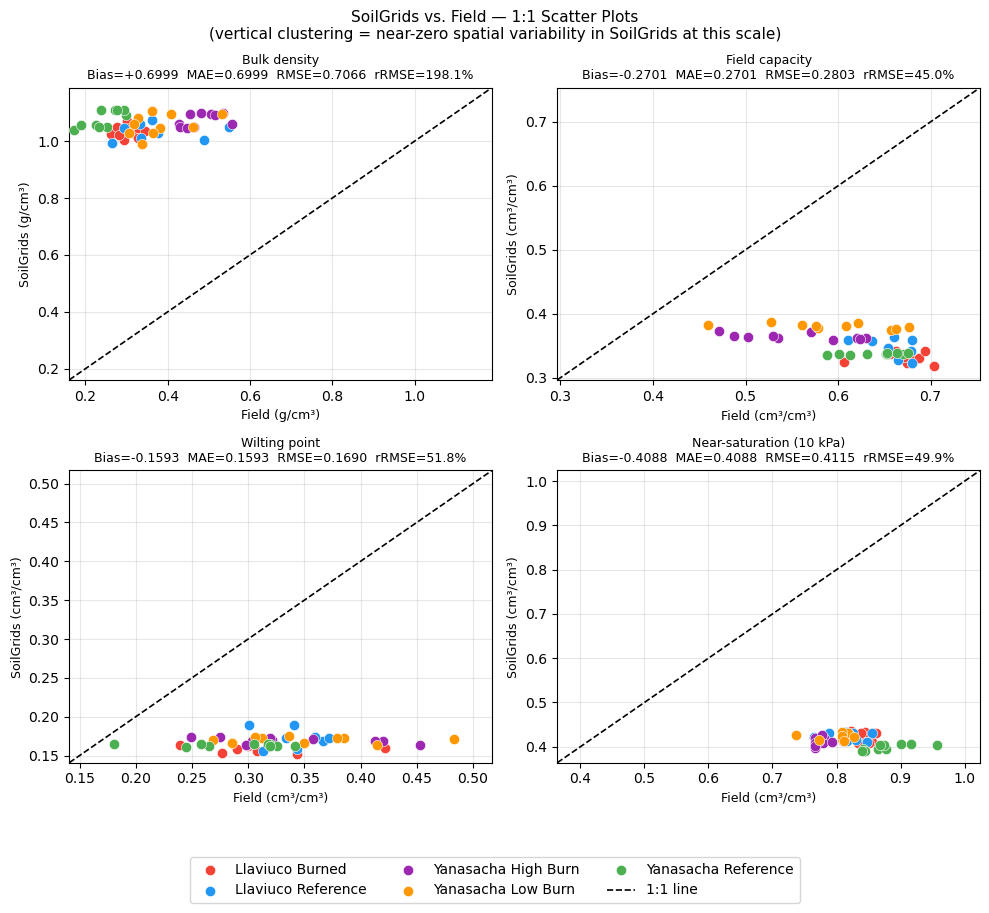

✓ Saved 'scatter_field_vs_soilgrids.png'


In [13]:

# ── Scatter plots with 1:1 line ───────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.flatten()

for ax, res in zip(axes, metrics_list):
    df_plot = combined[[res['field_col'], res['sg_col'], 'group']].dropna()

    for grp, gdf in df_plot.groupby('group'):
        ax.scatter(gdf[res['field_col']], gdf[res['sg_col']],
                   label=grp.replace('_', ' '), color=group_colors.get(grp, 'grey'),
                   s=55, edgecolors='white', linewidths=0.4, zorder=3)

    all_vals = pd.concat([df_plot[res['field_col']], df_plot[res['sg_col']]])
    lims = [all_vals.min() * 0.93, all_vals.max() * 1.07]
    ax.plot(lims, lims, 'k--', lw=1.2, label='1:1 line', zorder=2)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(f"Field ({res['unit']})", fontsize=9)
    ax.set_ylabel(f"SoilGrids ({res['unit']})", fontsize=9)
    sign = '+' if res['bias'] >= 0 else ''
    ax.set_title(
        f"{res['label']}\n"
        f"Bias={sign}{res['bias']:.4f}  MAE={res['mae']:.4f}  RMSE={res['rmse']:.4f}  rRMSE={res['rrmse']:.1f}%",
        fontsize=9
    )
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=10, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.02), frameon=True)

fig.suptitle("SoilGrids vs. Field — 1:1 Scatter Plots\n"
             "(vertical clustering = near-zero spatial variability in SoilGrids at this scale)",
             fontsize=11)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('scatter_field_vs_soilgrids.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved 'scatter_field_vs_soilgrids.png'")


In [8]:

# ── Kruskal–Wallis test: |error| across burn categories ───────────────────
# Tests whether the magnitude of SoilGrids error differs by burn group.
# H₀: all groups have the same distribution of |SoilGrids − Field|.

print("Kruskal–Wallis Test — |SoilGrids error| by burn group")
print("=" * 68)
print(f"{'Parameter':<32} {'H statistic':>12}  {'p-value':>9}  Result")
print("-" * 68)

for label, field_col, sg_col, unit in param_pairs:
    df = combined[[field_col, sg_col, 'group']].dropna().copy()
    df['abs_error'] = np.abs(df[sg_col] - df[field_col])
    group_samples = [g['abs_error'].values for _, g in df.groupby('group') if len(g) >= 3]
    if len(group_samples) < 2:
        print(f"{label:<32} {'—':>12}  {'—':>9}  insufficient groups")
        continue
    h_stat, p_val = stats.kruskal(*group_samples)
    sig = '*** p<0.001' if p_val < 0.001 else \
          ('**  p<0.01'  if p_val < 0.01  else \
          ('*   p<0.05'  if p_val < 0.05  else f'ns  p={p_val:.3f}'))
    print(f"{label:<32} {h_stat:>12.3f}  {p_val:>9.4f}  {sig}")

print("=" * 68)
print("H = Kruskal–Wallis statistic  |  ns = not significant at α=0.05")
print("\nObservations per group:")
print(combined.groupby('group').size().rename('n').to_string())


Kruskal–Wallis Test — |SoilGrids error| by burn group
Parameter                         H statistic    p-value  Result
--------------------------------------------------------------------
Bulk density                           16.304     0.0010  *** p<0.001
Field capacity                         25.412     0.0000  *** p<0.001
Wilting point                           1.567     0.6669  ns  p=0.667
Near-saturation (10 kPa)               18.810     0.0003  *** p<0.001
H = Kruskal–Wallis statistic  |  ns = not significant at α=0.05

Observations per group:
group
Llaviuco_Burned        10
Llaviuco_Reference      8
Yanasacha_High_Burn    10
Yanasacha_Low_Burn     10


In [2]:

# ── Export Wilcoxon + Error Metrics to Excel ──────────────────────────────

import pandas as pd
import numpy as np
from scipy import stats

combined = pd.read_csv('combined_field_soilgrids.csv')

param_pairs = [
    ('Bulk density',              'bulk_density_field_g_cm3',   'bdod_sg_g_cm3',       'g/cm³'),
    ('Field capacity',            'vwc_field_cap_field_cm3cm3', 'vwc_fc_sg_cm3cm3',    'cm³/cm³'),
    ('Wilting point',             'vwc_wilt_pt_field_cm3cm3',   'vwc_wp_sg_cm3cm3',    'cm³/cm³'),
    ('Near-saturation (10 kPa)', 'vwc_sat_field_cm3cm3',        'vwc_10kPa_sg_cm3cm3', 'cm³/cm³'),
]

rows = []
for label, field_col, sg_col, unit in param_pairs:
    df = combined[[field_col, sg_col]].dropna()
    n = len(df)

    # Wilcoxon
    if n >= 6:
        w_stat, p_wilcox = stats.wilcoxon(df[field_col].values, df[sg_col].values,
                                          alternative='two-sided')
        if   p_wilcox < 0.001: sig = '***'
        elif p_wilcox < 0.01:  sig = '**'
        elif p_wilcox < 0.05:  sig = '*'
        else:                  sig = 'ns'
    else:
        w_stat = p_wilcox = sig = None

    # Error metrics
    err   = df[sg_col].values - df[field_col].values
    bias  = float(np.mean(err))
    mae   = float(np.mean(np.abs(err)))
    rmse  = float(np.sqrt(np.mean(err ** 2)))
    rrmse = rmse / np.mean(df[field_col].values) * 100

    rows.append({
        'Parameter':          label,
        'Unit':               unit,
        'n':                  n,
        'Bias (SG−Field)':    round(bias, 5),
        'MAE':                round(mae, 5),
        'RMSE':               round(rmse, 5),
        'rRMSE (%)':          round(rrmse, 2),
        'Wilcoxon W':         round(w_stat, 1) if w_stat is not None else None,
        'p-value (Wilcoxon)': round(p_wilcox, 5) if p_wilcox is not None else None,
        'Significance':       sig,
    })

results_df = pd.DataFrame(rows)

out_excel = 'soilgrids_vs_field_statistics.xlsx'
with pd.ExcelWriter(out_excel, engine='openpyxl') as writer:
    results_df.to_excel(writer, sheet_name='Statistics', index=False)

    ws = writer.sheets['Statistics']

    # Auto-fit column widths
    for col in ws.columns:
        max_len = max(len(str(cell.value)) if cell.value is not None else 0 for cell in col)
        ws.column_dimensions[col[0].column_letter].width = max_len + 3

    # Bold header row
    from openpyxl.styles import Font, PatternFill, Alignment
    header_fill = PatternFill(start_color='1E88E5', end_color='1E88E5', fill_type='solid')
    for cell in ws[1]:
        cell.font = Font(bold=True, color='FFFFFF')
        cell.fill = header_fill
        cell.alignment = Alignment(horizontal='center')

    # Highlight significant results (p < 0.05)
    sig_fill = PatternFill(start_color='FFF9C4', end_color='FFF9C4', fill_type='solid')
    for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
        sig_val = row[9].value  # 'Significance' column (0-indexed col 9)
        if sig_val in ('*', '**', '***'):
            for cell in row:
                cell.fill = sig_fill

print(f"✓ Saved statistics to '{out_excel}'")
print(results_df.to_string(index=False))


✓ Saved statistics to 'soilgrids_vs_field_statistics.xlsx'
               Parameter    Unit  n  Bias (SG−Field)     MAE    RMSE  rRMSE (%)  Wilcoxon W  p-value (Wilcoxon) Significance
            Bulk density   g/cm³ 38          0.66492 0.66492 0.66937     173.47         0.0                 0.0          ***
          Field capacity cm³/cm³ 38         -0.26147 0.26147 0.27369      44.31         0.0                 0.0          ***
           Wilting point cm³/cm³ 38         -0.16851 0.16851 0.17723      52.72         0.0                 0.0          ***
Near-saturation (10 kPa) cm³/cm³ 38         -0.39028 0.39028 0.39150      48.34         0.0                 0.0          ***


In [21]:
import pandas as pd
from IPython.display import Markdown, display

# Load combined data if needed
try:
    combined
except NameError:
    combined = pd.read_csv('combined_field_soilgrids.csv')

# Site-level table (one row per site) and observation-level table (site x depth)
site_df = (
    combined[['Reference', 'Lat', 'Lon', 'Date', 'group']]
    .dropna(subset=['Reference', 'Lat', 'Lon'])
    .drop_duplicates(subset=['Reference'])
    .copy()
)
obs_df = combined[['Reference', 'depth', 'group']].dropna(subset=['Reference', 'depth']).copy()

# Sampling dates
site_df['Date_parsed'] = pd.to_datetime(site_df.get('Date'), errors='coerce')
valid_dates = site_df['Date_parsed'].dropna()
if len(valid_dates) > 0:
    date_start = valid_dates.min().strftime('%Y-%m-%d')
    date_end = valid_dates.max().strftime('%Y-%m-%d')
    n_sampling_dates = valid_dates.dt.date.nunique()
    date_text = f'{date_start} to {date_end} ({n_sampling_dates} sampling date(s))'
else:
    date_text = 'Date metadata not available in the loaded table'

# Sample counts
n_sites = site_df['Reference'].nunique()
n_observations = len(obs_df)

# Burned vs unburned
burn_mask_sites = site_df['group'].fillna('').str.contains('Burn', case=False)
burned_sites = int(burn_mask_sites.sum())
unburned_sites = int(n_sites - burned_sites)
burn_mask_obs = obs_df['group'].fillna('').str.contains('Burn', case=False)
burned_obs = int(burn_mask_obs.sum())
unburned_obs = int(n_observations - burned_obs)

# Sampling depth
depth_values = sorted(obs_df['depth'].dropna().astype(str).unique().tolist())
depth_text = ', '.join(depth_values) if depth_values else 'Depth metadata not available'

# Measured field parameters
measured_parameters = [
    'Soil organic matter (%)',
    'pH',
    'Bulk density (g/cm3)',
    'Volumetric water content at saturation (cm3/cm3)',
    'Volumetric water content at field capacity (cm3/cm3)',
    'Volumetric water content at wilting point (cm3/cm3)',
]
params_text = '; '.join(measured_parameters)

# Coordinate bounding box
lat_min = site_df['Lat'].min()
lat_max = site_df['Lat'].max()
lon_min = site_df['Lon'].min()
lon_max = site_df['Lon'].max()

summary_md = f"""
### Initial Field Data Summary

The field campaign includes **{n_sites} sites** and **{n_observations} total samples (site × depth observations)**.

- **Sampling dates:** {date_text}
- **Burned vs unburned sites:** {burned_sites} burned and {unburned_sites} unburned
- **Burned vs unburned samples:** {burned_obs} burned-associated and {unburned_obs} unburned-associated observations
- **Sampling depth intervals:** {depth_text}
- **Measured field parameters:** {params_text}
- **Coordinate bounding box (WGS84):**
  - Latitude: {lat_min:.5f} to {lat_max:.5f}
  - Longitude: {lon_min:.5f} to {lon_max:.5f}

Overall, the dataset captures both burned and reference conditions across two depth intervals, supporting an initial comparison of field-measured soil hydraulic properties with SoilGrids estimates.
"""

display(Markdown(summary_md))

quick_stats = pd.DataFrame({
    'metric': [
        'Number of sites',
        'Number of observations',
        'Burned sites',
        'Unburned sites',
        'Burned observations',
        'Unburned observations',
        'Depth intervals',
        'Measured field parameters',
        'Latitude min',
        'Latitude max',
        'Longitude min',
        'Longitude max',
    ],
    'value': [
        n_sites,
        n_observations,
        burned_sites,
        unburned_sites,
        burned_obs,
        unburned_obs,
        depth_text,
        params_text,
        round(float(lat_min), 5),
        round(float(lat_max), 5),
        round(float(lon_min), 5),
        round(float(lon_max), 5),
    ]
})

print('Quick summary table:')
display(quick_stats)


### Initial Field Data Summary

The field campaign includes **19 sites** and **38 total samples (site × depth observations)**.

- **Sampling dates:** 2025-11-25 to 2026-01-15 (4 sampling date(s))
- **Burned vs unburned sites:** 15 burned and 4 unburned
- **Burned vs unburned samples:** 30 burned-associated and 8 unburned-associated observations
- **Sampling depth intervals:** 0-10, 10-20
- **Measured field parameters:** Soil organic matter (%); pH; Bulk density (g/cm3); Volumetric water content at saturation (cm3/cm3); Volumetric water content at field capacity (cm3/cm3); Volumetric water content at wilting point (cm3/cm3)
- **Coordinate bounding box (WGS84):**
  - Latitude: -2.94465 to -2.80671
  - Longitude: -79.20765 to -79.13808

Overall, the dataset captures both burned and reference conditions across two depth intervals, supporting an initial comparison of field-measured soil hydraulic properties with SoilGrids estimates.


Quick summary table:


,metric,value
0,Number of sites,19
1,Number of observations,38
2,Burned sites,15
3,Unburned sites,4
4,Burned observations,30
5,Unburned observations,8
6,Depth intervals,"0-10, 10-20"
7,Measured field parameters,Soil organic matter (%); pH; Bulk density (g/c...
8,Latitude min,-2.94465
9,Latitude max,-2.80671
